# LDSTOP Method: Applied to sample means of IID random variables

This notebook accompanies the article **Stochastic optimisation method for estimating large deviations**.  
It demonstrates how the LDSTOP method can be used to estimate the large deviations of sample means of (continuous and discrete) IID random variables.

**Author:** Daniël W. H. Cloete  
**Date:** September 2026  
**Environment:** Python 3.12.3 (see `requirements.txt` / `runtime.txt`)

### Required packages download

In [ ]:
%pip install -r ../requirements.txt

### Imports

In [1]:
# plotting
%config InlineBackend.figure_format = 'svg'
import matplotlib.pyplot as plt
colors = ['#1f77b4', '#318c31', '#d62728']

# general
import numpy as np
import copy
from tqdm import tqdm

# torch
import torch
from torch.distributions import Bernoulli, Exponential
torch.set_default_dtype(torch.float64)

### LDSTOP method

In [3]:
def ldstop_IID(p, make_p_theta, theta, k_min, k_max, delta_k, n, N, M, alpha, score = False):
    """
    Parameters:
        p            (torch.distribution): original density/distribution
        make_p_theta (function):           function returning controlled density/distribution using theta
        theta        (torch.tensor):       parameter set with requires_grad=True
        k_min        (float):              minimum k value
        k_max        (float):              maximum k value
        delta_k      (float):              k value increment
        n            (int):                number of IID samples per epoch
        N            (int):                number of optimization epochs per k value
        M            (int):                number of final epochs estimates to construct final approximations
        alpha        (float):              initial learning rate for Adagrad optimizer
        score        (boolean):            boolean indicating the use of the score gradient instead of stochastic automatic differentiation

    Returns:
        I_est      (float array):       final rate function estimates
        A_est      (float array):       final observable value estimates
        SCGF_est   (float array):       final SCGF estimates
        ks         (float array):       corresponding k values
        theta_star (torch.tensor list): optimal parameter values
        As         (float array):       observable estimates over each optimization
        Ks         (float array):       KL divergence estimates over each optimization
        Ls         (float array):       loss estimates over each optimization
    """
    # number of k values
    num_ks = int(round(k_max/delta_k, 10)) + int(round(-k_min/delta_k, 10)) + 1
    # final estimate arrays
    I_est, A_est, SCGF_est, ks = np.zeros(num_ks), np.zeros(num_ks), np.zeros(num_ks), np.zeros(num_ks)
    theta_star = []
    # estimate tracking arrays
    As, Ks, Ls = np.zeros((num_ks, N)), np.zeros((num_ks, N)), np.zeros((num_ks, N))

    # initial k value
    k = 0
    k_index = 0

    # progress bar
    with tqdm(total=num_ks * N) as pbar:
        # k = 0 and positive k loop
        while k <= k_max:
            # average loss for baseline in score gradient
            L_ave = 0
            # adagrad optimizer for theta
            optimizer = torch.optim.Adagrad([theta], lr = alpha)

            for epoch in range(N):
                # generate n independent samples using theta
                p_theta = make_p_theta(theta)
                # score generation
                if score:
                    x = p_theta.sample((n,))
                # rsample generation
                else:
                    x = p_theta.rsample((n,))

                # observable, KL divergence, loss estimates
                A_i = x
                K_i = p_theta.log_prob(x) - p.log_prob(x)
                L_i = K_i - k*A_i
                A_n = A_i.mean()
                K_n = K_i.mean()
                L_n = L_i.mean()

                # gradient computation
                if score:
                    # important to detach the coefficients so that the gradient only passes through the log prob
                    grad_L = torch.autograd.grad(((L_i-L_ave).detach()*p_theta.log_prob(x)).mean(), theta, retain_graph=True)[0]
                else:
                    grad_L = torch.autograd.grad(L_n, theta, retain_graph=True)[0]

                # SGD step
                theta.grad = grad_L
                optimizer.step()
                optimizer.zero_grad()

                # record estimates
                As[k_index, epoch] = A_n.detach()
                Ks[k_index, epoch] = K_n.detach()
                Ls[k_index, epoch] = L_n.detach()

                # update average loss
                L_ave = (1-1/(epoch+1))*L_ave + (1/(epoch+1))*Ls[k_index, epoch]

                # progress bar update
                pbar.update(1)

            # final estimates averaged from last M epochs
            I_est[k_index] = np.mean(Ks[k_index, -M:])
            A_est[k_index] = np.mean(As[k_index, -M:])
            SCGF_est[k_index] = -np.mean(Ls[k_index, -M:])
            ks[k_index] = k
            theta_star.append(copy.deepcopy(theta))

            # increment k
            k += delta_k
            k_index += 1
            k = np.round(k, 10) # corrects rounding errors

        # reinitialize k and theta
        k = -delta_k
        theta = copy.deepcopy(theta_star[0])

        # negative k loop
        while k >= k_min:
            # average loss for baseline in score gradient
            L_ave = 0
            # adagrad optimizer for theta
            optimizer = torch.optim.Adagrad([theta], lr = alpha)

            for epoch in range(N):
                # generate n independent samples using theta
                p_theta = make_p_theta(theta)
                # score generation
                if score:
                    x = p_theta.sample((n,))
                # rsample generation
                else:
                    x = p_theta.rsample((n,))

                # observable, KL divergence, loss estimates
                A_i = x
                K_i = p_theta.log_prob(x) - p.log_prob(x)
                L_i = K_i - k*A_i
                A_n = A_i.mean()
                K_n = K_i.mean()
                L_n = L_i.mean()

                # gradient computation
                if score:
                    # important to detach the coefficients so that the gradient only passes through the log prob
                    grad_L = torch.autograd.grad(((L_i-L_ave).detach()*p_theta.log_prob(x)).mean(), theta, retain_graph=True)[0]
                else:
                    grad_L = torch.autograd.grad(L_n, theta, retain_graph=True)[0]

                # SGD step
                theta.grad = grad_L
                optimizer.step()
                optimizer.zero_grad()

                # record estimates
                As[k_index, epoch] = A_n.detach()
                Ks[k_index, epoch] = K_n.detach()
                Ls[k_index, epoch] = L_n.detach()

                # update average loss
                L_ave = (1-1/(epoch+1))*L_ave + (1/(epoch+1))*Ls[k_index, epoch]

                # progress bar update
                pbar.update(1)

            # final estimates averaged from last M epochs
            I_est[k_index] = np.mean(Ks[k_index, -M:])
            A_est[k_index] = np.mean(As[k_index, -M:])
            SCGF_est[k_index] = -np.mean(Ls[k_index, -M:])
            ks[k_index] = k
            theta_star.append(copy.deepcopy(theta))

            # decrement k
            k -= delta_k
            k_index += 1
            k = np.round(k, 10) # corrects rounding errors

    return I_est, A_est, SCGF_est, ks, theta_star, As, Ks, Ls

### Results plotting function

In [4]:
def plot_results(I_est, A_est, SCGF_est, ks, As, Ks, Ls, I = 0, SCGF = 0):
    # figure and subplots
    fig, axs = plt.subplots(3, 2, figsize=(9, 9))
    ax1, ax2 = axs[0]
    ax3, ax4 = axs[1]
    ax5, ax6 = axs[2]

    # rate function
    ax1.scatter(A_est, I_est, color=colors[2], marker='x', zorder=2)
    if I != 0:
        a_plot = np.linspace(np.min(A_est), np.max(A_est), 1000)
        ax1.plot(a_plot, I(a_plot), color='black', zorder=1)
    ax1.set_xlabel(r'$a$')
    ax1.set_ylabel(r'$I(a)$')
    ax1.spines['bottom'].set_position(('data', 0))
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # scaled cumulant generating function
    k_min = np.min(ks)
    k_max = np.max(ks)
    ax2.scatter(ks, SCGF_est, color=colors[0], marker='x', zorder=2)
    if SCGF != 0:
        k_plot = np.linspace(k_min, k_max, 1000)
        ax2.plot(k_plot, SCGF(k_plot), color='black', zorder=1)
    ax2.set_xlabel(r'$k$')
    ax2.set_ylabel(r'$\lambda(k)$')
    ax2.spines['bottom'].set_position(('data', 0))
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    col_i = [0 if k == 0 else 1 if k > 0 else 2 for k in ks]
    alphs = [1 if k == 0 else k/k_max if k > 0 else k/k_min for k in ks]

    # observable and KL estimates
    epochs = np.arange(1, len(As[0])+1)
    for i in range(len(As)):
        ax3.plot(epochs, As[i], color=colors[col_i[i]], alpha=alphs[i])
        ax4.plot(epochs, Ks[i], color=colors[col_i[i]], alpha=alphs[i])
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel(r'$A_T$')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel(r'$K_T$')

    # loss and scaled loss
    for i in range(len(As)):
        ax5.plot(epochs, Ls[i], color=colors[col_i[i]], alpha=alphs[i])
        ax6.plot(epochs, Ls[i] + SCGF_est[i], color=colors[col_i[i]], alpha=alphs[i])
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel(r'$L_T$')
    ax6.set_xlabel('Epoch')
    ax6.set_ylabel(r'Scaled $L_T$')

    fig.tight_layout(w_pad=3, rect=[0, 0, 1, 0.96])
    phi = (1 + np.sqrt(5)) / 2
    for ax in axs.flat:
        ax.set_box_aspect(1 / phi)
    return fig

### Exponential random variables

100%|██████████| 5500/5500 [00:02<00:00, 2214.26it/s]


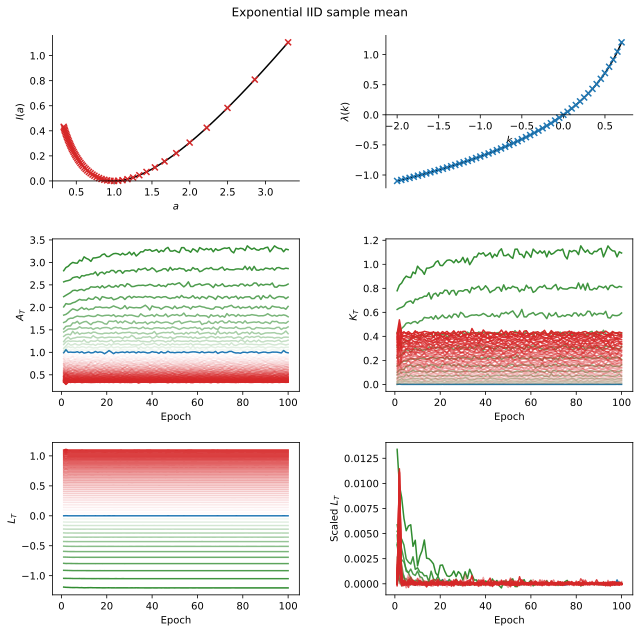

In [5]:
# problem parameters 
mu = 1.0
p = Exponential(1/mu)

# algorithm parameters
make_p_theta = lambda theta: Exponential(1.0/theta)
theta = torch.tensor([mu], requires_grad=True)
k_min = -2.0
k_max = 0.7
delta_k = 0.05
n = 10000
N = 100
M = 25
alpha = 0.05

# ldstop method
I_est, A_est, SCGF_est, ks, theta_star, As, Ks, Ls = ldstop_IID(p, make_p_theta, theta, k_min, k_max, delta_k, n, N, M, alpha)

# true functions
def I(a):
    return a/mu - 1 - np.log(a/mu)

def SCGF(k):
    return np.log(1/(1-mu*k))

# plotting
fig = plot_results(I_est, A_est, SCGF_est, ks, As, Ks, Ls, I, SCGF)
fig.suptitle('Exponential IID sample mean')
plt.show()

### Bernoulli random variables

100%|██████████| 775/775 [00:00<00:00, 1836.28it/s]


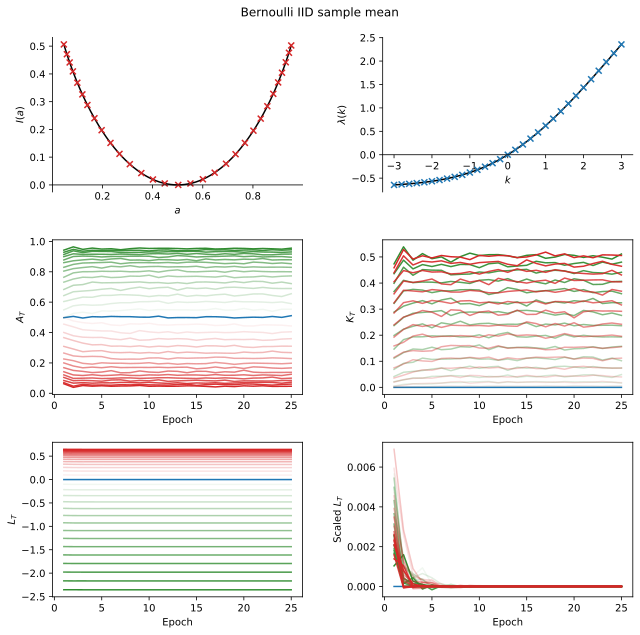

In [6]:
# problem parameters 
prob = 0.5
p = Bernoulli(prob)

# algorithm parameters
make_p_theta = lambda theta: Bernoulli(torch.clamp(theta, 0.0, 1.0))
theta = torch.tensor([prob], requires_grad=True)
k_min = -3
k_max = 3
delta_k = 0.2
n = 10000
N = 25
M = 10
alpha = 0.02

# ldstop method
I_est, A_est, SCGF_est, ks, theta_star, As, Ks, Ls = ldstop_IID(p, make_p_theta, theta, k_min, k_max, delta_k, n, N, M, alpha, score=True)

# true functions
def I(a):
    return a*np.log(a/prob) + (1-a)*np.log((1-a)/(1-prob))

def SCGF(k):
    return np.log(1 - prob + prob*np.exp(k))

# plotting
fig = plot_results(I_est, A_est, SCGF_est, ks, As, Ks, Ls, I, SCGF)
fig.suptitle('Bernoulli IID sample mean')
plt.show()